In [46]:
words = open("names.txt", "r").read().splitlines()

len(words)

32033

## Bigrams Model using NN

In [47]:
import torch

In [48]:
# We need to get all the unique character in the dataset of number which is simply all 26 character of the alphabet 
a = set(''.join(words)) # gets all the unique characters from the huge string 
chars = sorted(list(set(''.join(words)))) # we want it as a sorted list 
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [49]:
# Because computers only understand numbers, we need to map each character to a number 
# So we need a look up table for 
# stoi - string to interger
# itos = integer to string 

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."] = 0
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [50]:
# integer to string 
# get the reverse of stoi 
itos = {i: s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [51]:
# create training set of all the bigrams 

xs, ys = [], [] # training set: inputs and labels 

for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # map ch1 to its integer value 
        ix2 = stoi[ch2] # map ch2 to its integer value 
        print(ch1, ch2)
        print(ix1, ix2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
        

. e
0 5
e m
5 13
m m
13 13
m a
13 1
a .
1 0


In [52]:
xs 

tensor([ 0,  5, 13, 13,  1])

In [53]:
ys

tensor([ 5, 13, 13,  1,  0])

In [54]:
# above, xs is the input dataset, and ys is the target dataset 
# when xs = 0 (char at index 0), we want our NN to predict 5 (assign high probability to the char at index 5)
# when xs = 5 (char at index 5), we want out NN to predict 13 (assign high probability to char at index 13)
# and so on ... 

# xs - input data 
# ys - target output 

# xs and ys is our simple dataset and we are going to create a simple neural network which will be trained on the xs and ys dataset 

In [55]:
# the simple mathematics of a neural net is that we multiply a weight by the input x plus a bias b
# wx + b 

# From the xs input data, out input values are integer values and we know that we cannot use integer values as an input into the NN 
# Also feeding the input values as numbers with magnitude will lead the NN to treat these numbers like there is a numerical relationship
# This false numerical relationship will mislead the NN and thats not what we want 
# 
# To resolve this, we encode the inputs using vectors 
# Each input is represented as a vector of all zeros except a single 1 at the character's index 
# 'a' (index 1) → [0, 1, 0, 0, 0, ...]
# 'b' (index 2) → [0, 0, 1, 0, 0, ...]
# 'c' (index 3) → [0, 0, 0, 1, 0, ...]

# By encoding the inputs as vectors, every character is equidistant from every other character 
# no character is numerically larger, smaller, or closer to another

import torch.nn.functional as F 
xenc = F.one_hot(xs, num_classes=27).float()
xenc # This gives us five rows with 27 columns 
# each row is a seperate input encoded with the index value position set to 1 

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [56]:
xenc.shape

torch.Size([5, 27])

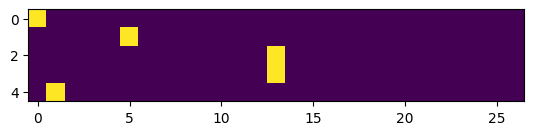

In [57]:
import matplotlib.pyplot as plt
plt.imshow(xenc)

In [58]:
# One problem you should always watch out for is the dtype of your inputs into a NN 
# The datatype should always be floats which can take on a range of values 

xenc.dtype # was initially int dtype until we casted it above 

# so solve this, we cast xenc to float when we encode above 

torch.float32

In [59]:
# create random weights 
W = torch.randn((27, 27))
W

tensor([[-4.8281e-01, -3.7486e+00,  2.1238e+00,  1.4759e+00,  7.8576e-01,
         -1.1456e+00, -1.5519e+00, -5.7790e-01,  1.1594e+00,  3.1930e-01,
         -7.5113e-01,  1.0622e+00,  9.2635e-01, -3.6733e-01, -8.7629e-01,
         -2.6502e-01,  1.1319e+00, -1.2989e+00, -1.8935e+00,  8.4683e-01,
          2.9748e-01,  4.5043e-01, -1.0059e+00,  2.6019e-01, -5.0109e-01,
          1.9471e+00, -8.3212e-01],
        [-2.4160e+00,  1.2412e+00,  2.6812e-01, -2.3418e-01,  1.1324e+00,
         -3.8286e-01, -1.2831e+00, -1.0333e+00, -2.8034e-01,  1.4821e+00,
          7.3448e-01,  3.3449e-01,  1.0768e+00,  1.4480e-01,  7.9139e-01,
         -1.9080e-01, -8.7354e-01, -5.1673e-01, -1.1966e+00, -5.0701e-01,
         -2.1656e+00, -5.4127e-01,  1.5039e+00, -6.5696e-01, -3.3076e-01,
         -1.4956e+00,  1.9984e+00],
        [ 1.0016e-01, -7.9728e-01, -4.8398e-01, -8.2978e-01,  1.2090e+00,
         -2.7272e-01,  1.9256e-01, -1.8281e+00, -1.8386e+00,  7.8560e-02,
          3.3340e-01, -1.0079e+00, -1.72

In [ ]:
# perform x @ W 
# x = (5, 27) 
# W = (27, 27)

# The idea is that each of the 5 rows has 27 columns (dimension)
# Each of the 27 columns (dimension) will represent probability distribution for the next characters - 
# it will represent the probabilities of the next characters 

# We are going to treat the ypred as log counts and exponentiate them 
logits = xenc @ W # intepret this as the log-counts

# The two lines of code below is known as softmax - takes logits (output of an NN layer) as inputs, exponentiates and normalizes which will always sum to 1 
counts = logits.exp() # exponentiate logits to convert negative logits to its positive equivalent 
probs = counts / counts.sum(1, keepdim=True) # Normalize each row independently so that it sums to 1 - this will represent the probabilities of the next character given the input of that row 

# probs becomes our ypred = (5, 27)

# Because of the transformation (calculations) done above, we can now interpret probs as the probabilities of the next characters
probs # see this as ypred

# In Summary, this block of code is regarded as the forward pass
# It is made up of differentiable operations 
# We can backpropagate through all of the operation which means: 
# --- we can calculate the gradient of each operation which will tell us how each weight value affects the final loss 
# --- then we can tune the weight appropriately to minimize the final loss 

tensor([[0.0130, 0.0005, 0.1761, 0.0921, 0.0462, 0.0067, 0.0045, 0.0118, 0.0671,
         0.0290, 0.0099, 0.0609, 0.0532, 0.0146, 0.0088, 0.0162, 0.0653, 0.0057,
         0.0032, 0.0491, 0.0284, 0.0330, 0.0077, 0.0273, 0.0128, 0.1476, 0.0092],
        [0.0151, 0.0273, 0.0860, 0.0504, 0.0505, 0.0077, 0.0191, 0.0350, 0.0105,
         0.0346, 0.1127, 0.0359, 0.0096, 0.0403, 0.0094, 0.0320, 0.0046, 0.0162,
         0.0404, 0.0234, 0.0105, 0.1069, 0.1097, 0.0498, 0.0050, 0.0096, 0.0479],
        [0.0303, 0.0166, 0.0130, 0.0696, 0.0062, 0.0911, 0.0358, 0.0076, 0.0225,
         0.0231, 0.0451, 0.0804, 0.0896, 0.0378, 0.0340, 0.0046, 0.0164, 0.1062,
         0.0652, 0.0881, 0.0199, 0.0451, 0.0075, 0.0065, 0.0162, 0.0055, 0.0160],
        [0.0303, 0.0166, 0.0130, 0.0696, 0.0062, 0.0911, 0.0358, 0.0076, 0.0225,
         0.0231, 0.0451, 0.0804, 0.0896, 0.0378, 0.0340, 0.0046, 0.0164, 0.1062,
         0.0652, 0.0881, 0.0199, 0.0451, 0.0075, 0.0065, 0.0162, 0.0055, 0.0160],
        [0.0021, 0.0828,